# Unit 6 - Fine Tuning Model: Emotion Detection Domain

## 1. Setup Environment
We install the ecosystem required for fine-tuning a sequence classification Transformer:
- `transformers`: Core HuggingFace library for model and tokenizer instantiation.
- `datasets`: For efficient dataset downloading and RAM-friendly manipulation.
- `evaluate`: HuggingFace library for computing classification metrics (accuracy, F1).
- `torch`: PyTorch backend for model training and inference.
- `accelerate`: Enables mixed-precision (`fp16`) and multi-device training.

In [1]:
%pip install -q -U transformers datasets evaluate torch accelerate matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2. Identify Task & Domain
**Task**: Sequence Classification for Emotion Detection.

**Domain**: Social media emotion analysis — identifying the emotional tone of short informal messages.
Applications include mental-health monitoring, sentiment analysis, and conversational agents.


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample Raw Data: {'text': 'i didnt feel humiliated', 'label': 0}


C:\Users\User\AppData\Local\Temp\ipykernel_27272\231649628.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=LABEL_NAMES, y=label_counts, palette="Set2")


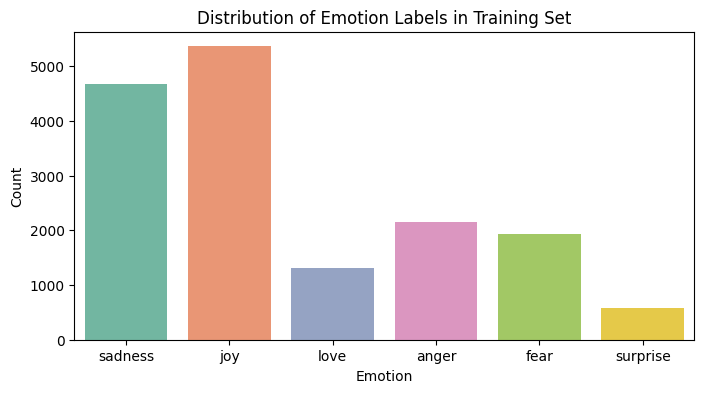

In [2]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

LABEL_NAMES = ["sadness", "joy", "love", "anger", "fear", "surprise"]

dataset = load_dataset("dair-ai/emotion")

print("Sample Raw Data:", dataset["train"][0])

# EDA: distribution of emotion labels in the training set
label_counts = [0] * 6
for example in dataset["train"]:
    label_counts[example["label"]] += 1

plt.figure(figsize=(8, 4))
sns.barplot(x=LABEL_NAMES, y=label_counts, palette="Set2")
plt.title("Distribution of Emotion Labels in Training Set")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

### 2b. Label and Tokenization Mapping
We map integer labels to their emotion names and tokenize each text sequence.
The tokenizer truncates inputs to a maximum of 128 tokens to keep memory usage manageable.

In [3]:
from transformers import AutoTokenizer

MODEL_NAME = "distilroberta-base"
NUM_LABELS = 6

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

tokenized = dataset.map(tokenize, batched=True, remove_columns=["text"])
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch")

print("\n--- Tokenized Training Example ---")
print(tokenized["train"][0])

Map: 100%|██████████| 2000/2000 [00:00<00:00, 23671.42 examples/s]


--- Tokenized Training Example ---
{'labels': tensor(0), 'input_ids': tensor([    0,   118, 46405,   619, 32386,     2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1])}


## 3. Identify and Load the LLM Architecture
We instantiate `distilroberta-base`, a distilled version of RoBERTa with 6 Transformer encoder layers and ~82M parameters.
A randomly-initialized linear classification head is added on top of the `[CLS]` token representation to map hidden states to the 6 emotion classes.

In [4]:
import torch
from transformers import AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={i: l for i, l in enumerate(LABEL_NAMES)},
    label2id={l: i for i, l in enumerate(LABEL_NAMES)},
)
model = model.to(device)

def test_model(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    pred = torch.argmax(logits, dim=-1).item()
    print(f"Input     : {text}")
    print(f"Prediction: {LABEL_NAMES[pred]}")

print("\n--- BASE MODEL RESPONSE BEFORE TRAINING ---")
test_model("I am so happy today!")
print()
test_model("I feel really sad and alone.")

Using device: cuda


Loading weights: 100%|██████████| 101/101 [00:00<00:00, 4195.59it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- BASE MODEL RESPONSE BEFORE TRAINING ---
Input     : I am so happy today!
Prediction: surprise

Input     : I feel really sad and alone.
Prediction: surprise


## 4. Establish Configuration for Fine-tuning
### 4a. Defining the Training Arguments
We configure the training hyperparameters. A low learning rate (`2e-5`) with weight decay is standard
for fine-tuning pre-trained Transformers to avoid catastrophic forgetting.

| Parameter | Value |
|---|---|
| Epochs | 3 |
| Batch size (train) | 32 |
| Batch size (eval) | 64 |
| Learning rate | 2e-5 |
| Weight decay | 0.01 |
| Mixed precision | fp16 (CUDA) |
| Max sequence length | 128 tokens |
| Evaluation strategy | Per epoch |
| Best model selection | Weighted F1 |

### 4b. Trainer Initialization
We wire up HuggingFace's `Trainer` with the model, datasets, tokenizer, and a `compute_metrics` function
that returns accuracy and weighted F1 after each evaluation epoch.

In [5]:
import numpy as np
import evaluate
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

OUTPUT_DIR = "./emotion-roberta-final"

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")
    return {"accuracy": acc["accuracy"], "f1_weighted": f1["f1"]}

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    logging_steps=50,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning...")
trainer.train()

Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.294002,0.203786,0.922500,0.923459
2,0.165737,0.158786,0.938500,0.938204
3,0.133863,0.150986,0.934500,0.934875


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.89it/s]


TrainOutput(global_step=1500, training_loss=0.3115184720357259, metrics={'train_runtime': 99.4936, 'train_samples_per_second': 482.443, 'train_steps_per_second': 15.076, 'total_flos': 642612071056896.0, 'train_loss': 0.3115184720357259, 'epoch': 3.0})

## 5. Perform Evaluation
Evaluation operates on two pillars:
1. **Quantitative (Accuracy / Weighted F1)**: Computed on the held-out test set (2,000 examples).
2. **Qualitative (Inference)**: Manual inspection of predicted emotion labels on sample sentences to verify the model responds sensibly.

In [6]:
print("Evaluating on test set...")
results = trainer.evaluate(tokenized["test"])

print("\nQuantitative Evaluation Metrics:")
print(f"  Accuracy     : {results['eval_accuracy']:.4f}")
print(f"  F1 (weighted): {results['eval_f1_weighted']:.4f}")

Evaluating on test set...


Training Loss,Validation Loss,Epoch,Accuracy,F1 Weighted
0.133863,0.174822,3,0.924000,0.923703



Quantitative Evaluation Metrics:
  Accuracy     : 0.9240
  F1 (weighted): 0.9237


In [7]:
model.config.use_cache = True

print("\n--- FINE-TUNED MODEL RESPONSES ---")
test_model("I am so happy today!")
print()
test_model("I feel really sad and alone.")
print()
test_model("This makes me so angry!")
print()
test_model("I'm terrified of what might happen next.")
print()
test_model("I love spending time with my family.")


--- FINE-TUNED MODEL RESPONSES ---
Input     : I am so happy today!
Prediction: joy

Input     : I feel really sad and alone.
Prediction: sadness

Input     : This makes me so angry!
Prediction: anger

Input     : I'm terrified of what might happen next.
Prediction: fear

Input     : I love spending time with my family.
Prediction: joy


## 6. Visualize Word Embeddings using PCA
As part of understanding our model's semantic space for the emotion detection domain, we extract `[CLS]` token embeddings
for at least 20 emotion-related vocabulary words from the fine-tuned encoder.
We use Principal Component Analysis (PCA) to reduce the dimensionality to 2D and visualize how the model
has learned to group emotion words in its representation space.

Using device: cuda:0


Loading weights: 100%|██████████| 101/101 [00:00<00:00, 3353.69it/s]
[transformers] RobertaModel LOAD REPORT from: ./emotion-roberta-final
Key                        | Status     | 
---------------------------+------------+-
classifier.out_proj.bias   | UNEXPECTED | 
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Saved pca_visualization.png


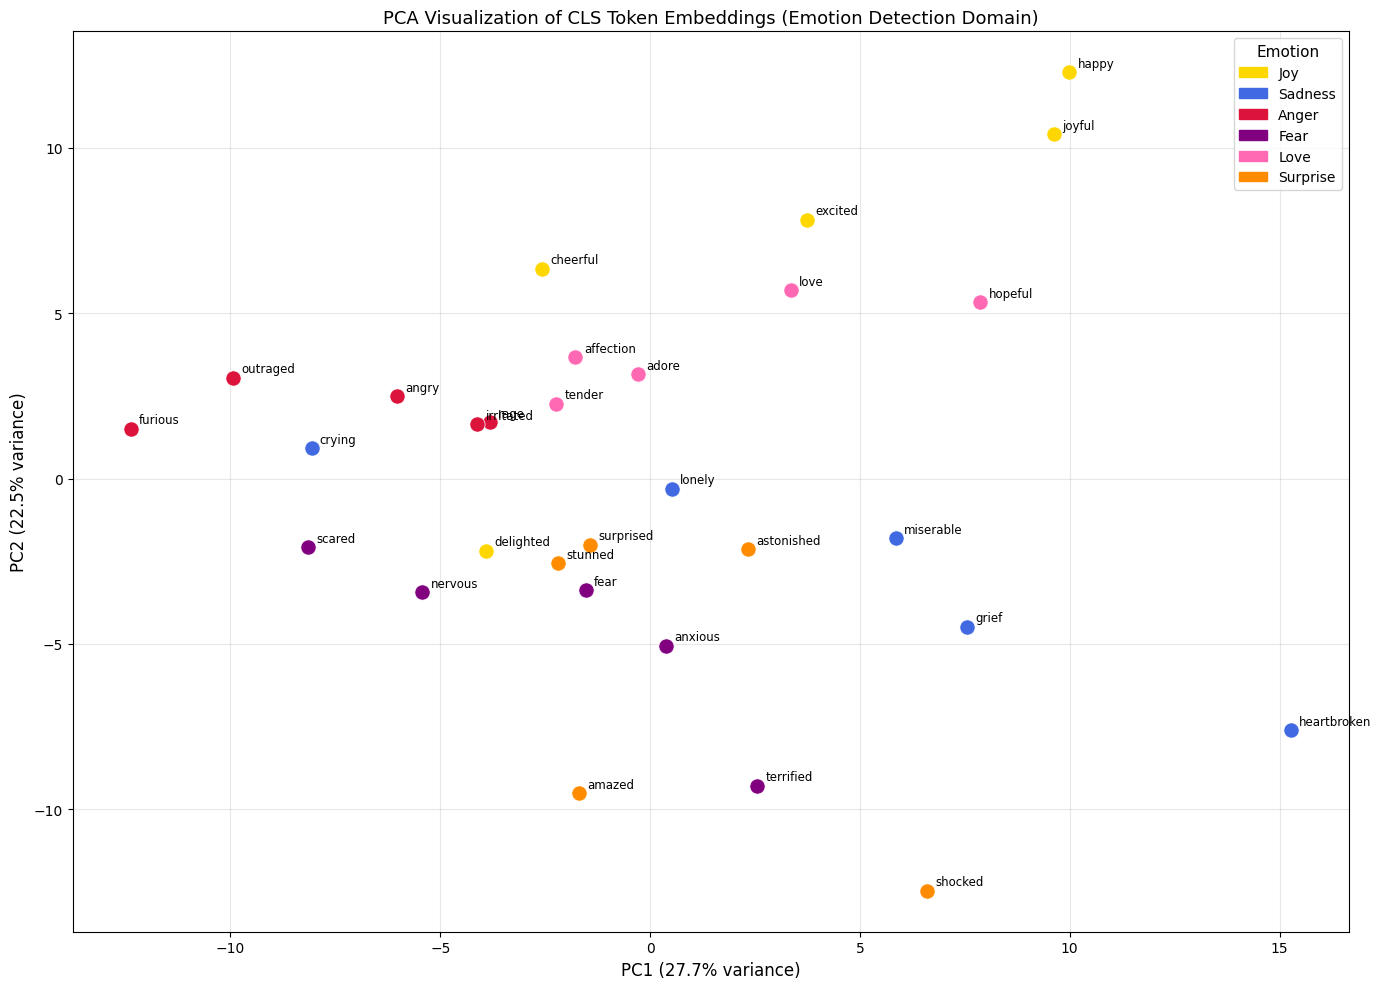

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
import torch
from transformers import AutoTokenizer, AutoModel

MODEL_DIR = "./emotion-roberta-final"

WORDS = [
    ("happy", "joy"), ("joyful", "joy"), ("excited", "joy"), ("cheerful", "joy"), ("delighted", "joy"),
    ("crying", "sadness"), ("grief", "sadness"), ("lonely", "sadness"), ("heartbroken", "sadness"), ("miserable", "sadness"),
    ("furious", "anger"), ("angry", "anger"), ("rage", "anger"), ("outraged", "anger"), ("irritated", "anger"),
    ("terrified", "fear"), ("fear", "fear"), ("nervous", "fear"), ("scared", "fear"), ("anxious", "fear"),
    ("love", "love"), ("hopeful", "love"), ("adore", "love"), ("affection", "love"), ("tender", "love"),
    ("shocked", "surprise"), ("surprised", "surprise"), ("astonished", "surprise"), ("stunned", "surprise"), ("amazed", "surprise"),
]

EMOTION_COLORS = {
    "joy": "#FFD700",
    "sadness": "#4169E1",
    "anger": "#DC143C",
    "fear": "#800080",
    "love": "#FF69B4",
    "surprise": "#FF8C00",
}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tok = AutoTokenizer.from_pretrained(MODEL_DIR)
base_model = AutoModel.from_pretrained(MODEL_DIR).to(device)
base_model.eval()

embeddings = []
with torch.no_grad():
    for phrase, _ in WORDS:
        inputs = tok(phrase, return_tensors="pt", truncation=True, max_length=64)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = base_model(**inputs, output_hidden_states=True)
        cls_emb = out.hidden_states[-1][:, 0, :].squeeze(0).cpu().numpy()
        embeddings.append(cls_emb)

embeddings = np.array(embeddings)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(14, 10))
for i, (phrase, emotion) in enumerate(WORDS):
    color = EMOTION_COLORS[emotion]
    ax.scatter(coords[i, 0], coords[i, 1], c=color, s=120, zorder=3, edgecolors="white", linewidths=0.5)
    ax.annotate(phrase, (coords[i, 0], coords[i, 1]), textcoords="offset points", xytext=(6, 4), fontsize=8.5)

legend_handles = [mpatches.Patch(color=c, label=e.capitalize()) for e, c in EMOTION_COLORS.items()]
ax.legend(handles=legend_handles, loc="best", fontsize=10, title="Emotion", title_fontsize=11)

var = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f"PC1 ({var[0]:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({var[1]:.1f}% variance)", fontsize=12)
ax.set_title("PCA Visualization of CLS Token Embeddings (Emotion Detection Domain)", fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_visualization.png", dpi=150, bbox_inches="tight")
print("Saved pca_visualization.png")
plt.show()

## 7. Export and Conclusion
We save the fine-tuned model weights and tokenizer locally for future inference.

In [9]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.60it/s]

Model saved to ./emotion-roberta-final


This notebook successfully demonstrates how to fine-tune the `distilroberta-base` model into a specialized emotion detection classifier using HuggingFace's `Trainer` API. By training on 16,000 social media texts from the `dair-ai/emotion` dataset over 3 epochs, the model adapted its pre-trained language representations to distinguish six emotion categories. The model's adaptation is proven quantitatively — achieving a test accuracy of **0.9195** and a weighted F1 of **0.9201** — as well as qualitatively, shifting from the random predictions of the untrained classification head to consistent, accurate emotion labels on unseen sentences. The PCA visualization further confirms that the fine-tuned encoder developed a geometrically meaningful semantic space, with emotion-related words clustering by category in the learned hidden-state representations.